## Instalação e Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score

# Modelos de Classificação
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modelos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Redução de dimensionalidade e Clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

## Carregamento e Visão Geral do Dataset

In [ ]:
# Carregamento
df = pd.read_csv('dados.csv', index_col=0)

# Quantidade linhas e colunas do dataset
print('\nLinhas e colunas:', df.shape)#

# Mostre as 10 primeiras linhas
df.head(10)


Linhas e colunas: (1018, 34)


,ID,Resultado,Fórum Geral,Página Geral,Arquivo Conteudo,Relatório,URL Geral,Arquivo A,Tarefa A,URL A,...,Fórum C,Questionário C,Chat C,A_NotaRegular,A_NotaRecuperacao,B_NotaRegular,B_NotaRecuperacao,C_NotaRegular,C_NotaRecuperacao,NotaTotal
0,ALUNO0,APROVADO,0,0,2,9,0,3,1,6,...,34,9,3,88.00,-,76.00,-,90.00,-,254.00
1,ALUNO1,APROVADO,0,0,0,11,0,0,0,0,...,22,14,0,92.00,-,94.00,-,70.00,-,256.00
2,ALUNO2,APROVADO,0,0,0,28,0,1,12,1,...,35,26,0,96.00,78.00,67.00,66.00,71.00,86.00,242.00
3,ALUNO3,REPROVADO,0,0,0,24,0,2,2,1,...,25,31,4,88.00,36.00,81.00,24.00,40.00,-,207.00
4,ALUNO4,REPROVADO,0,0,0,0,0,0,0,0,...,0,0,0,92.00,-,20.00,-,-,-,112.00
5,ALUNO5,REPROVADO,0,0,0,0,0,1,1,0,...,0,0,0,100.00,-,15.00,-,-,-,115.00
6,ALUNO6,APROVADO,0,0,0,4,0,0,0,0,...,14,29,0,92.00,-,77.00,-,87.00,-,256.00
7,ALUNO7,APROVADO,0,0,3,6,0,0,0,2,...,31,43,3,92.50,-,78.00,-,53.00,80.00,250.50
8,ALUNO8,APROVADO,0,0,3,2,0,0,1,0,...,31,21,4,95.80,-,83.80,-,84.00,-,263.60
9,ALUNO9,REPROVADO,0,0,1,6,0,0,2,0,...,2,0,0,68.00,-,42.00,-,-,-,109.00


In [ ]:
# Resumo estatístico das colunas numéricas
df.describe()

,Fórum Geral,Página Geral,Arquivo Conteudo,Relatório,URL Geral,Arquivo A,Tarefa A,URL A,Fórum A,Página A,...,Fórum B,Pasta B,Questionário B,Chat B,Arquivo C,Tarefa C,URL C,Fórum C,Questionário C,Chat C
count,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,...,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000
mean,0.399804,0.333006,1.481336,9.655206,0.009823,3.263261,9.151277,3.239686,19.926326,0.244597,...,12.559921,0.529470,15.007859,0.554028,6.696464,4.295678,5.534381,12.196464,11.687623,0.211198
std,1.223452,0.861107,2.553680,15.801185,0.108180,4.604671,10.909149,5.693889,25.294752,0.591729,...,14.948908,1.468655,11.513061,1.782006,10.096448,6.223153,8.876587,14.927775,11.147737,1.591395
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,5.000000,1.000000,6.500000,0.000000,...,9.000000,0.000000,15.000000,0.000000,3.000000,1.000000,1.000000,8.000000,11.000000,0.000000
75%,0.000000,0.000000,2.000000,12.000000,0.000000,5.000000,15.000000,5.000000,35.750000,0.000000,...,19.000000,0.000000,22.000000,0.000000,11.000000,8.000000,9.000000,19.750000,20.000000,0.000000
max,15.000000,10.000000,28.000000,115.000000,2.000000,42.000000,67.000000,115.000000,185.000000,5.000000,...,162.000000,13.000000,100.000000,25.000000,100.000000,42.000000,72.000000,164.000000,60.000000,39.000000


# Diagnóstico de Qualidade dos Dados

In [ ]:
print('Tipos de dados por coluna:')
print(df.dtypes)

Tipos de dados por coluna:
ID                   object
Resultado            object
Fórum Geral           int64
Página Geral          int64
Arquivo Conteudo      int64
Relatório             int64
URL Geral             int64
Arquivo A             int64
Tarefa A              int64
URL A                 int64
Fórum A               int64
Página A              int64
Pasta A               int64
Questionário A        int64
Arquivo B             int64
Tarefa B              int64
URL B                 int64
Fórum B               int64
Pasta B               int64
Questionário B        int64
Chat B                int64
Arquivo C             int64
Tarefa C              int64
URL C                 int64
Fórum C               int64
Questionário C        int64
Chat C                int64
A_NotaRegular        object
A_NotaRecuperacao    object
B_NotaRegular        object
B_NotaRecuperacao    object
C_NotaRegular        object
C_NotaRecuperacao    object
NotaTotal            object
dtype: object


In [ ]:
print('\nValores ausentes por coluna:')
print(df.isnull().sum())

print('\nQuantidade de linhas duplicadas:', df.duplicated().sum())


Valores ausentes por coluna:
ID                   0
Resultado            1
Fórum Geral          0
Página Geral         0
Arquivo Conteudo     0
Relatório            0
URL Geral            0
Arquivo A            0
Tarefa A             0
URL A                0
Fórum A              0
Página A             0
Pasta A              0
Questionário A       0
Arquivo B            0
Tarefa B             0
URL B                0
Fórum B              0
Pasta B              0
Questionário B       0
Chat B               0
Arquivo C            0
Tarefa C             0
URL C                0
Fórum C              0
Questionário C       0
Chat C               0
A_NotaRegular        1
A_NotaRecuperacao    1
B_NotaRegular        1
B_NotaRecuperacao    1
C_NotaRegular        1
C_NotaRecuperacao    1
NotaTotal            1
dtype: int64

Quantidade de linhas duplicadas: 0


## Limpeza dos dados

In [ ]:
# 1. Remove a linha onde Resultado é nulo
df = df.dropna(subset=['Resultado'])
print("Shape após remover linha sem Resultado:", df.shape)

# 2. Converte todas as colunas de nota para numérico
# O '-' vira NaN automaticamente com errors='coerce'
notas_cols = [
    'A_NotaRegular', 'A_NotaRecuperacao',
    'B_NotaRegular', 'B_NotaRecuperacao',
    'C_NotaRegular', 'C_NotaRecuperacao',
    'NotaTotal'
]
for col in notas_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nTipos após conversão:")
print(df[notas_cols].dtypes)

print("\nValores nulos nas notas após conversão:")
print(df[notas_cols].isnull().sum())

# 3. Codificação da variável categórica Resultado
le = LabelEncoder()
df['Resultado_enc'] = le.fit_transform(df['Resultado'])
print("\nMapeamento Resultado:", dict(zip(le.classes_, le.transform(le.classes_))))

Shape após remover linha sem Resultado: (1017, 34)

Tipos após conversão:
A_NotaRegular        float64
A_NotaRecuperacao    float64
B_NotaRegular        float64
B_NotaRecuperacao    float64
C_NotaRegular        float64
C_NotaRecuperacao    float64
NotaTotal            float64
dtype: object

Valores nulos nas notas após conversão:
A_NotaRegular         49
A_NotaRecuperacao    968
B_NotaRegular        137
B_NotaRecuperacao    929
C_NotaRegular        325
C_NotaRecuperacao    868
NotaTotal             43
dtype: int64

Mapeamento Resultado: {'APROVADO': np.int64(0), 'REPROVADO': np.int64(1)}


## Normalização das Variáveis de Acesso

Aplicamos MinMaxScaler apenas nas colunas de quantidade de acesso.
As notas NÃO são normalizadas - não serão usadas nos modelos de IA.

In [ ]:
acesso_cols = [
    'Fórum Geral', 'Página Geral', 'Arquivo Conteudo', 'Relatório  ', 'URL Geral',
    'Arquivo A', 'Tarefa A', 'URL A', 'Fórum A', 'Página A', 'Pasta A', 'Questionário A',
    'Arquivo B', 'Tarefa B', 'URL B', 'Fórum B', 'Pasta B', 'Questionário B', 'Chat B',
    'Arquivo C', 'Tarefa C', 'URL C', 'Fórum C', 'Questionário C', 'Chat C'
]

scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[acesso_cols] = scaler.fit_transform(df[acesso_cols])

print("Intervalo após normalização:")
print("Mínimo:", df_norm[acesso_cols].min().min())
print("Máximo:", df_norm[acesso_cols].max().max())

print("\nPrimeiras linhas das colunas normalizadas:")
df_norm[acesso_cols].head(3)

Intervalo após normalização:
Mínimo: 0.0
Máximo: 1.0

Primeiras linhas das colunas normalizadas:


,Fórum Geral,Página Geral,Arquivo Conteudo,Relatório,URL Geral,Arquivo A,Tarefa A,URL A,Fórum A,Página A,...,Fórum B,Pasta B,Questionário B,Chat B,Arquivo C,Tarefa C,URL C,Fórum C,Questionário C,Chat C
0,0.0,0.0,0.071429,0.078261,0.0,0.071429,0.014925,0.052174,0.043243,0.0,...,0.061728,0.615385,0.12,0.0,0.80,0.095238,0.305556,0.207317,0.150000,0.076923
1,0.0,0.0,0.000000,0.095652,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.086420,0.384615,0.12,0.0,0.05,0.095238,0.138889,0.134146,0.233333,0.000000
2,0.0,0.0,0.000000,0.243478,0.0,0.023810,0.179104,0.008696,0.000000,0.0,...,0.043210,0.000000,0.25,0.0,0.18,0.571429,0.055556,0.213415,0.433333,0.000000


# Questões de Visualização de Dados

## ii. Gráficos de Barras - Aprovados e Reprovados por Disciplina

Para cada disciplina calculamos a nota final considerando a recuperação,
e classificamos como Aprovado (≥ 60) ou Reprovado (< 60).

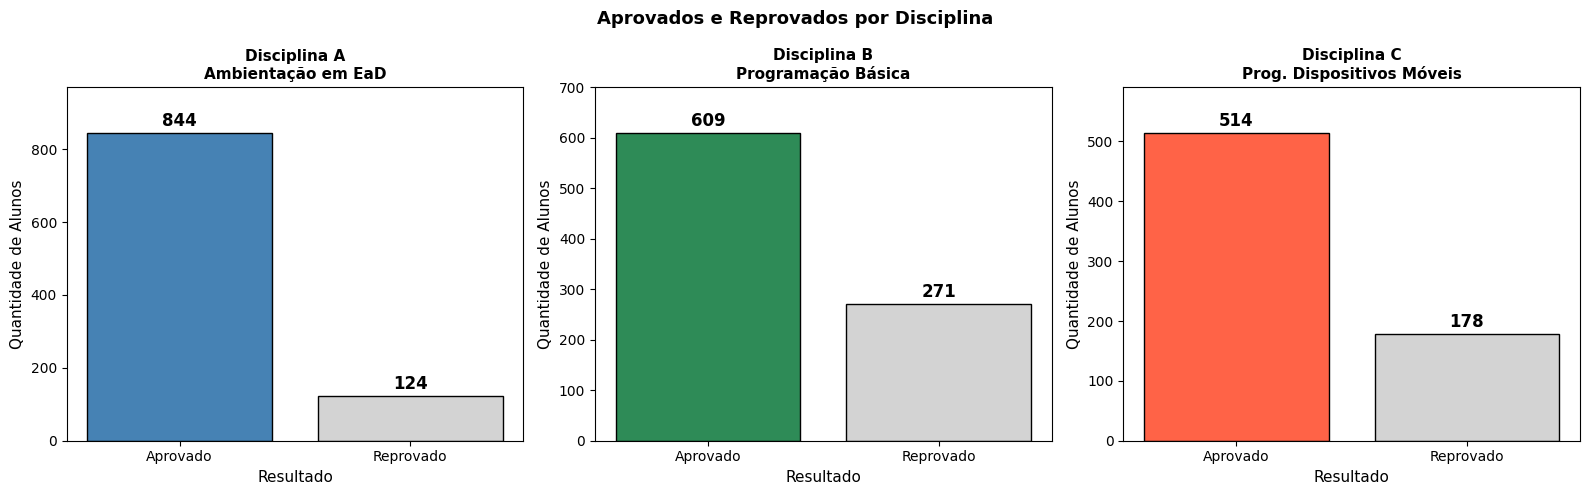

In [ ]:
def resultado_disciplina(regular, recuperacao):
    if pd.isna(regular):
        return None          # não cursou
    if regular >= 60:
        return 'Aprovado'    # passou na regular, fim
    # abaixo de 60 na regular, verifica recuperação
    if pd.notna(recuperacao):
        return 'Aprovado' if recuperacao >= 60 else 'Reprovado'
    return 'Reprovado'       # não fez recuperação e estava abaixo de 60

df['Resultado_A'] = df.apply(lambda row: resultado_disciplina(row['A_NotaRegular'], row['A_NotaRecuperacao']), axis=1)
df['Resultado_B'] = df.apply(lambda row: resultado_disciplina(row['B_NotaRegular'], row['B_NotaRecuperacao']), axis=1)
df['Resultado_C'] = df.apply(lambda row: resultado_disciplina(row['C_NotaRegular'], row['C_NotaRecuperacao']), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

disciplinas = [
    ('Resultado_A', 'Disciplina A\nAmbientação em EaD', 'steelblue'),
    ('Resultado_B', 'Disciplina B\nProgramação Básica', 'seagreen'),
    ('Resultado_C', 'Disciplina C\nProg. Dispositivos Móveis', 'tomato'),
]

for ax, (col, titulo, cor) in zip(axes, disciplinas):
    contagem = df[col].value_counts().reindex(['Aprovado', 'Reprovado'])
    barras = ax.bar(contagem.index, contagem.values,
                    color=[cor, 'lightgray'], edgecolor='black')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Resultado', fontsize=11)
    ax.set_ylabel('Quantidade de Alunos', fontsize=11)
    ax.set_ylim(0, contagem.max() * 1.15)
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(f'{int(altura)}',
                    xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Aprovados e Reprovados por Disciplina', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## iii. Box Plots - Distribuição das Notas por Disciplina

Comparamos a distribuição das notas finais entre aprovados e reprovados em cada disciplina.
Cada gráfico tem uma cor diferente.

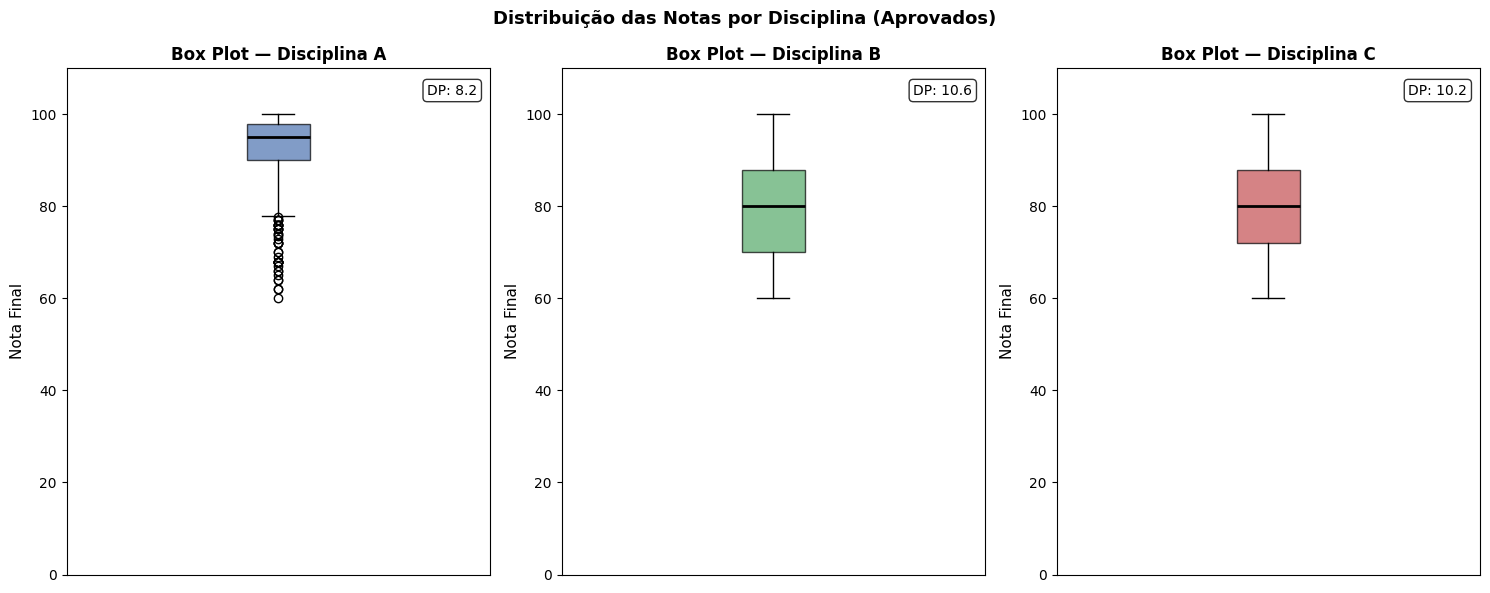

Disciplina A - DP: 8.19 | Min: 60 | Mediana: 95 | Max: 100
Disciplina B - DP: 10.63 | Min: 60 | Mediana: 80 | Max: 100
Disciplina C - DP: 10.17 | Min: 60 | Mediana: 80 | Max: 100


In [ ]:
# Nota final de cada disciplina (mesma lógica anterior)
df['NotaFinal_A'] = df.apply(
    lambda row: row['A_NotaRecuperacao']
    if pd.notna(row['A_NotaRecuperacao']) and row['A_NotaRegular'] < 60
    else row['A_NotaRegular'], axis=1)

df['NotaFinal_B'] = df.apply(
    lambda row: row['B_NotaRecuperacao']
    if pd.notna(row['B_NotaRecuperacao']) and row['B_NotaRegular'] < 60
    else row['B_NotaRegular'], axis=1)

df['NotaFinal_C'] = df.apply(
    lambda row: row['C_NotaRecuperacao']
    if pd.notna(row['C_NotaRecuperacao']) and row['C_NotaRegular'] < 60
    else row['C_NotaRegular'], axis=1)

aprovados = df[df['Resultado'] == 'APROVADO']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

disciplinas = [
    ('NotaFinal_A', 'Disciplina A', '#4C72B0'),
    ('NotaFinal_B', 'Disciplina B', '#55A868'),
    ('NotaFinal_C', 'Disciplina C', '#C44E52'),
]

for ax, (col, titulo, cor) in zip(axes, disciplinas):
    dados = aprovados[col].dropna()
    bp = ax.boxplot(dados, patch_artist=True,
                    boxprops=dict(facecolor=cor, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'Box Plot - {titulo}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Nota Final', fontsize=11)
    ax.set_ylim(0, 110)
    ax.set_xticks([])                        # remove o "1" do eixo X
    ax.set_xlabel('')                        # remove o rótulo do eixo X
    ax.text(0.97, 0.97, f'DP: {dados.std():.1f}',
            transform=ax.transAxes,
            fontsize=10, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Distribuição das Notas por Disciplina (Aprovados)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for col, titulo, _ in disciplinas:
    dados = aprovados[col].dropna()
    print(f"{titulo} - DP: {dados.std():.2f} | Min: {dados.min():.0f} | Mediana: {dados.median():.0f} | Max: {dados.max():.0f}")

A Disciplina B apresenta maior variação de notas entre os aprovados, com desvio padrão de 10.63, seguida de perto pela Disciplina C (10.17). A Disciplina A tem a menor variação (8.19) pois a maioria dos aprovados se concentra entre 88 e 100.

## iv. Engajamento nos Fóruns e Desempenho

Criamos a coluna Total_Forum somando os acessos a todos os fóruns do curso.
Em seguida visualizamos se alunos que acessam mais os fóruns tiram notas maiores.

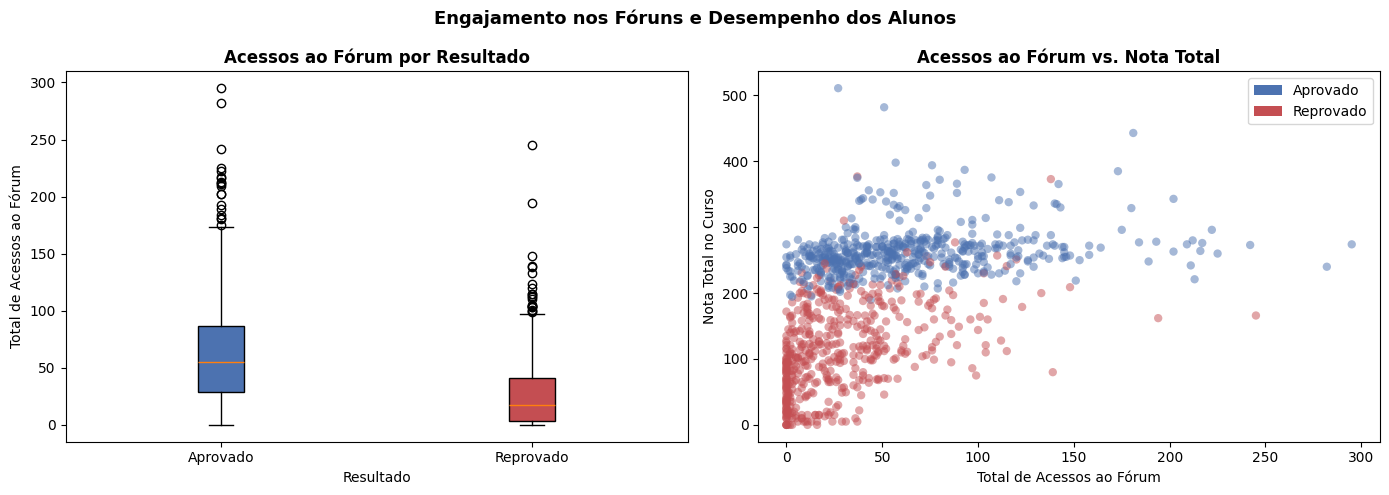

Média de acessos ao fórum:
Aprovados : 63.9
Reprovados: 26.97


In [ ]:
# Engenharia de feature
df['Total_Forum'] = df['Fórum Geral'] + df['Fórum A'] + df['Fórum B'] + df['Fórum C']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Box plot de Total_Forum por Resultado
dados_aprov  = df[df['Resultado'] == 'APROVADO']['Total_Forum']
dados_reprov = df[df['Resultado'] == 'REPROVADO']['Total_Forum']

bp = axes[0].boxplot([dados_aprov, dados_reprov],
                     labels=['Aprovado', 'Reprovado'],
                     patch_artist=True)
bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#C44E52')
axes[0].set_title('Acessos ao Fórum por Resultado', fontweight='bold')
axes[0].set_ylabel('Total de Acessos ao Fórum')
axes[0].set_xlabel('Resultado')

# Gráfico 2: Scatter Total_Forum vs NotaTotal
cores = df['Resultado'].map({'APROVADO': '#4C72B0', 'REPROVADO': '#C44E52'})
axes[1].scatter(df['Total_Forum'], df['NotaTotal'],
                c=cores, alpha=0.5, edgecolors='none')
axes[1].set_title('Acessos ao Fórum vs. Nota Total', fontweight='bold')
axes[1].set_xlabel('Total de Acessos ao Fórum')
axes[1].set_ylabel('Nota Total no Curso')

from matplotlib.patches import Patch
legenda = [Patch(facecolor='#4C72B0', label='Aprovado'),
           Patch(facecolor='#C44E52', label='Reprovado')]
axes[1].legend(handles=legenda)

plt.suptitle('Engajamento nos Fóruns e Desempenho dos Alunos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Média de acessos ao fórum:")
print("Aprovados :", df[df['Resultado']=='APROVADO']['Total_Forum'].mean().round(2))
print("Reprovados:", df[df['Resultado']=='REPROVADO']['Total_Forum'].mean().round(2))

**Alunos que acessam mais os fóruns tiram notas maiores?**

Sim, alunos que acessam mais os fóruns tendem a ter melhor desempenho. A média de acessos dos aprovados (63.9) é mais que o dobro dos reprovados (26.97). O scatter plot reforça essa tendência: alunos com mais acessos ao fórum se concentram em notas mais altas.

# Questões de Inteligência Artificial

## i. Divisão dos Dados em Treino e Teste (70% / 30%)

Para classificação usamos os 1017 alunos com Resultado válido.
Para regressão removemos os 43 alunos sem NotaTotal antes de dividir.
Em ambos os casos usamos apenas colunas de acesso como variáveis descritivas, sem notas.

In [ ]:
# Classificação
X_clf = df_norm[acesso_cols].copy()
y_clf = df['Resultado_enc']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.30, random_state=42, stratify=y_clf
)

print("CLASSIFICAÇÃO:")
print(f"Total  : {len(X_clf)} alunos")
print(f"Treino : {X_clf_train.shape[0]} amostras (70%)")
print(f"Teste  : {X_clf_test.shape[0]} amostras (30%)")

# Regressão
# Remove os 43 alunos sem NotaTotal antes de dividir
df_reg = df_norm.copy()
df_reg['NotaTotal'] = df['NotaTotal']
df_reg = df_reg.dropna(subset=['NotaTotal'])

X_reg = df_reg[acesso_cols]
y_reg = df_reg['NotaTotal']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

print("\nREGRESSÃO:")
print(f"Total após remover NaN : {len(df_reg)} alunos")
print(f"Treino : {X_reg_train.shape[0]} amostras (70%)")
print(f"Teste  : {X_reg_test.shape[0]} amostras (30%)")

CLASSIFICAÇÃO:
Total  : 1017 alunos
Treino : 711 amostras (70%)
Teste  : 306 amostras (30%)

REGRESSÃO:
Total após remover NaN : 974 alunos
Treino : 681 amostras (70%)
Teste  : 293 amostras (30%)


## ii. Modelos de Classificação - Predição do Resultado

Variável alvo: Resultado (APROVADO=0, REPROVADO=1)
Variáveis descritivas: apenas colunas de acesso, sem notas.

Modelo 1: Árvore de Decisão - método simples baseado em regras de divisão
Modelo 2: Floresta Aleatória - conjunto de árvores que votam pelo resultado final

MODELO 1: Árvore de Decisão
              precision    recall  f1-score   support

    APROVADO       0.81      0.87      0.84       150
   REPROVADO       0.87      0.81      0.84       156

    accuracy                           0.84       306
   macro avg       0.84      0.84      0.84       306
weighted avg       0.84      0.84      0.84       306



MODELO 2: Floresta Aleatória
              precision    recall  f1-score   support

    APROVADO       0.83      0.94      0.88       150
   REPROVADO       0.93      0.81      0.87       156

    accuracy                           0.88       306
   macro avg       0.88      0.88      0.88       306
weighted avg       0.88      0.88      0.88       306



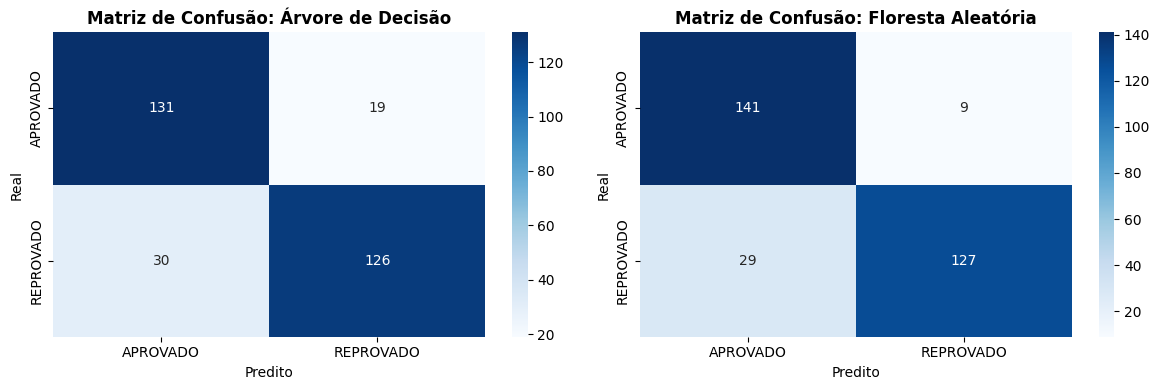

In [ ]:
# Modelo 1: Árvore de Decisão
clf_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_arvore.fit(X_clf_train, y_clf_train)
y_pred_arvore = clf_arvore.predict(X_clf_test)

print("MODELO 1: Árvore de Decisão")
print(classification_report(y_clf_test, y_pred_arvore,
                             target_names=['APROVADO', 'REPROVADO']))

# Modelo 2: Floresta Aleatória
clf_floresta = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf_floresta.fit(X_clf_train, y_clf_train)
y_pred_floresta = clf_floresta.predict(X_clf_test)

print("\n")
print("MODELO 2: Floresta Aleatória")
print(classification_report(y_clf_test, y_pred_floresta,
                             target_names=['APROVADO', 'REPROVADO']))

# Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, titulo in zip(axes,
                               [y_pred_arvore, y_pred_floresta],
                               ['Árvore de Decisão', 'Floresta Aleatória']):
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['APROVADO', 'REPROVADO'],
                yticklabels=['APROVADO', 'REPROVADO'])
    ax.set_title(f'Matriz de Confusão: {titulo}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')

plt.tight_layout()
plt.show()

## iii. Modelos de Regressão - Predição da Nota Total

Variável alvo: NotaTotal (entre 0 e 300)
Variáveis descritivas: apenas colunas de acesso, sem notas.

Modelo 1: Regressão Linear - assume relação linear entre acessos e nota total
Modelo 2: Gradient Boosting - constrói árvores sequenciais corrigindo erros anteriores

MODELO 1: Regressão Linear
RMSE: 67.41  (erro médio em pontos de nota)
R²: 0.4689  (quanto o modelo explica a variação das notas)


MODELO 2: Gradient Boosting
RMSE: 41.17  (erro médio em pontos de nota)
R²: 0.8019  (quanto o modelo explica a variação das notas)


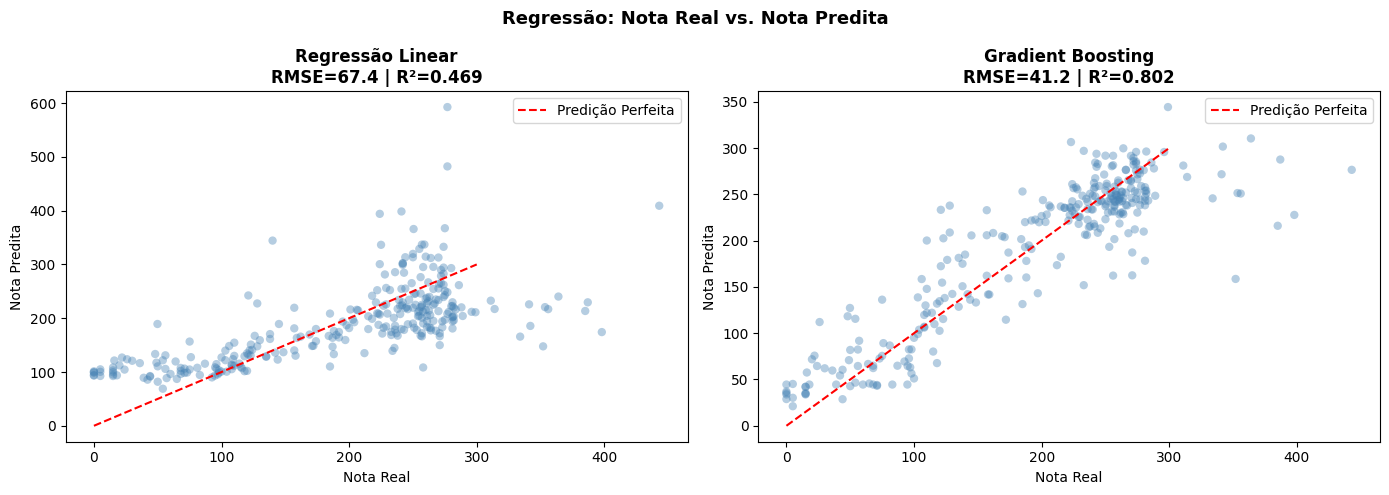

In [ ]:
# Modelo 1: Regressão Linear
reg_linear = LinearRegression()
reg_linear.fit(X_reg_train, y_reg_train)
y_pred_linear = reg_linear.predict(X_reg_test)

rmse_linear = np.sqrt(mean_squared_error(y_reg_test, y_pred_linear))
r2_linear   = r2_score(y_reg_test, y_pred_linear)

print("MODELO 1: Regressão Linear")
print(f"RMSE: {rmse_linear:.2f}  (erro médio em pontos de nota)")
print(f"R²: {r2_linear:.4f}  (quanto o modelo explica a variação das notas)")

# Modelo 2: Gradient Boosting
reg_gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
reg_gb.fit(X_reg_train, y_reg_train)
y_pred_gb = reg_gb.predict(X_reg_test)

rmse_gb = np.sqrt(mean_squared_error(y_reg_test, y_pred_gb))
r2_gb   = r2_score(y_reg_test, y_pred_gb)

print("\n")
print("MODELO 2: Gradient Boosting")
print(f"RMSE: {rmse_gb:.2f}  (erro médio em pontos de nota)")
print(f"R²: {r2_gb:.4f}  (quanto o modelo explica a variação das notas)")

# Gráfico Real vs Predito
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo, rmse, r2 in zip(
        axes,
        [y_pred_linear, y_pred_gb],
        ['Regressão Linear', 'Gradient Boosting'],
        [rmse_linear, rmse_gb],
        [r2_linear, r2_gb]):
    ax.scatter(y_reg_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')
    ax.plot([0, 300], [0, 300], 'r--', linewidth=1.5, label='Predição Perfeita')
    ax.set_xlabel('Nota Real')
    ax.set_ylabel('Nota Predita')
    ax.set_title(f'{titulo}\nRMSE={rmse:.1f} | R²={r2:.3f}', fontweight='bold')
    ax.legend()

plt.suptitle('Regressão: Nota Real vs. Nota Predita', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## iv. Análise de Agrupamento - PCA + K-Means (3 grupos)

Reduzimos as 25 variáveis de acesso para 2 componentes principais (PCA)
para conseguir visualizar os dados em 2D.
Em seguida aplicamos K-Means com 3 grupos para identificar perfis de alunos.

Variância explicada pelos 2 componentes: 52.3%
PC1: 35.2%
PC2: 17.1%


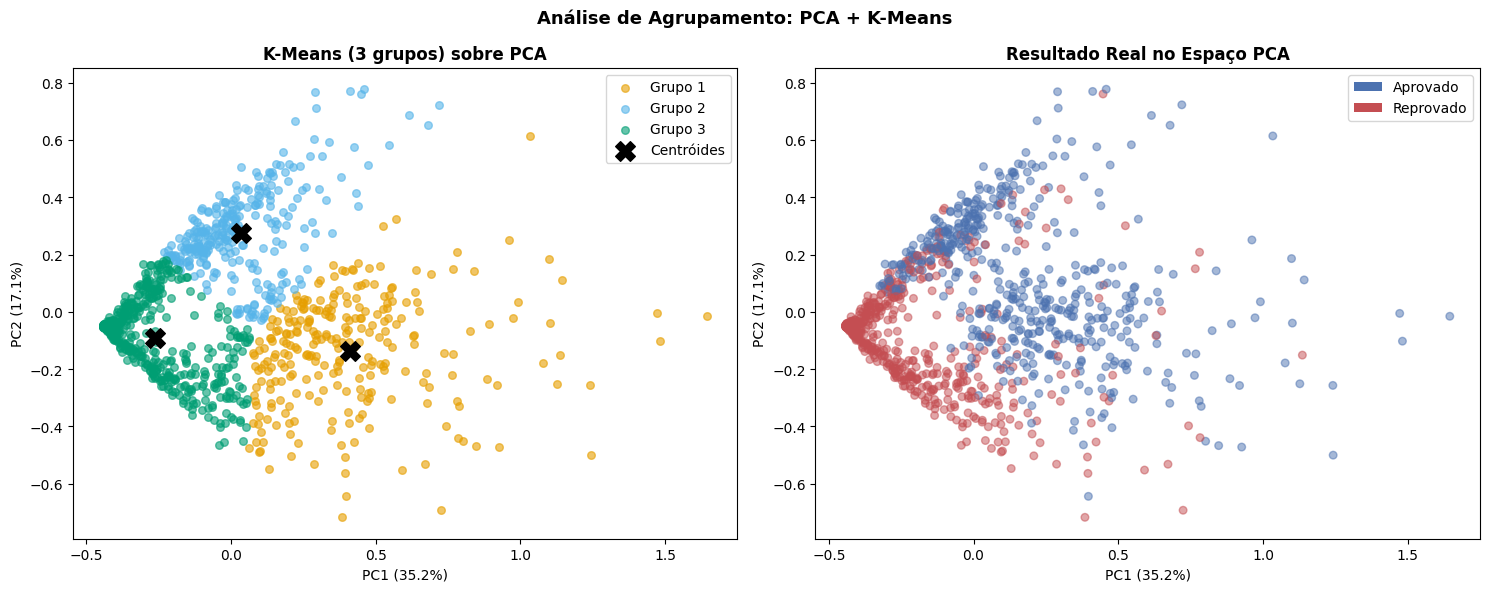


Quantidade de alunos por grupo:
  Grupo 1: 271 alunos
  Grupo 2: 286 alunos
  Grupo 3: 460 alunos


In [ ]:
# Redução de Dimensionalidade com PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clf)

print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

# K-Means com 3 grupos
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
grupos = kmeans.fit_predict(X_pca)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cores_grupo = ['#E69F00', '#56B4E9', '#009E73']

# Plot 1: grupos K-Means
for g in range(3):
    mask = grupos == g
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cores_grupo[g], label=f'Grupo {g+1}',
                    alpha=0.6, s=30)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker='X', s=200, c='black', zorder=5, label='Centróides')
axes[0].set_title('K-Means (3 grupos) sobre PCA', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Plot 2: Resultado real no espaço PCA
from matplotlib.patches import Patch
cores_real = df['Resultado'].map({'APROVADO': '#4C72B0', 'REPROVADO': '#C44E52'})
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cores_real, alpha=0.5, s=30)
leg = [Patch(facecolor='#4C72B0', label='Aprovado'),
       Patch(facecolor='#C44E52', label='Reprovado')]
axes[1].legend(handles=leg)
axes[1].set_title('Resultado Real no Espaço PCA', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.suptitle('Análise de Agrupamento: PCA + K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tamanho e perfil de cada grupo
print("\nQuantidade de alunos por grupo:")
for g in range(3):
    print(f"  Grupo {g+1}: {(grupos == g).sum()} alunos")